## Libraries

In [76]:
import numpy as np
#from scipy.signal import lfilter, firwin
from pylab import *
from scipy.fftpack import fft,fftshift
import scipy.signal as signal
from tool._fixedInt import *


# Set up y generacion de señal

## Creacion de señal


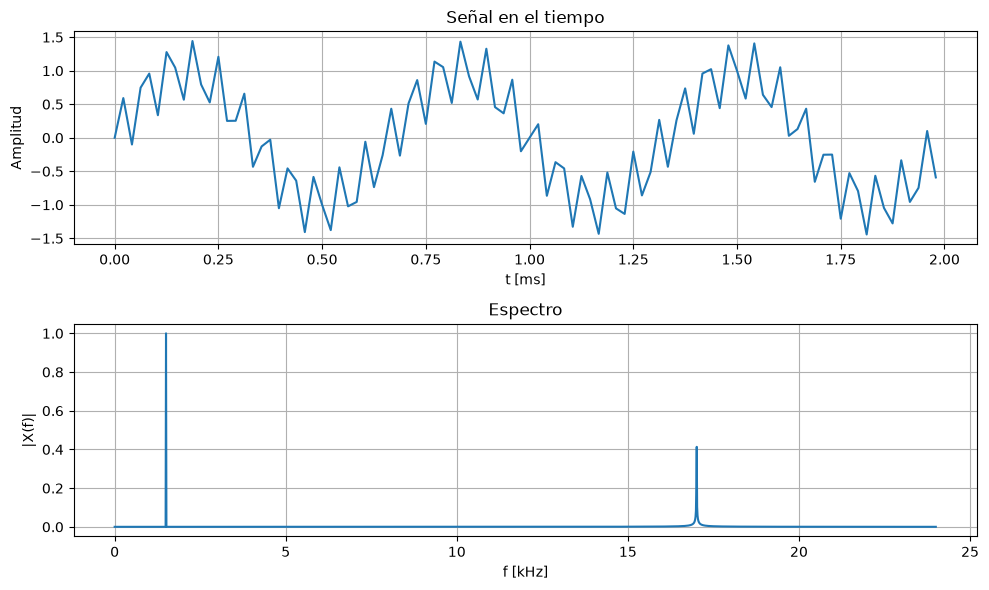

In [77]:
# Parametros generales
fs = 48e3
N  = 4096
t  = np.arange(N) / fs

# Primer tono
F_1 = 17e3                  # NOTA: Se ve horribla (en tiempo) esta señal, no por N, sino por lo baja de la fs
A_1 = 0.5
signal_1  = A_1 * np.sin(2*np.pi*F_1*t)

# Segundo tono
F_2 = 1.5e3
A_2 = 1.0
signal_2  = A_2 * np.sin(2*np.pi*F_2*t)

# Armado de ña señal
signal_gen = signal_1 + signal_2
 

#################### FFT ####################

fft_signal = fft(signal_gen,N)
xfft       = np.linspace(0.0, 1.0/(2.0*t[1]), N//2)


# Ploteos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

n_show = int(2e-3 * fs)
ax1.plot(t[:n_show]*1e3, signal_gen[:n_show])
ax1.set_xlabel('t [ms]')
ax1.set_ylabel('Amplitud')
ax1.set_title('Señal en el tiempo')
ax1.grid(True)

ax2.plot(xfft/1e3, 2.0/N * np.abs(fft_signal[:N//2]))
ax2.set_xlabel('f [kHz]')
ax2.set_ylabel('|X(f)|')
ax2.set_title('Espectro')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Utilities

In [78]:
def to_db(x):
    return 20 * np.log10(np.abs(x) + 1e-50) # 1e-50 para que no devuelva 0 

## Creacion del filtro

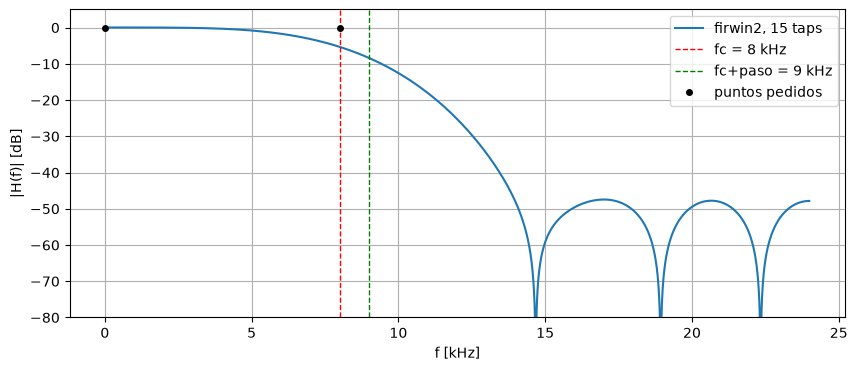

In [79]:
taps = 15
fc   = 8e3 
paso = 1e3
freq = [0, fc, fc + paso, fs/2]      
gain = [1, 1, 0, 0]
h = signal.firwin2(taps, freq, gain, fs=fs)
w, H = signal.freqz(h, worN=N, fs=fs)
H_db = to_db(H)


# Plots
plt.figure(figsize=(10, 4))
plt.plot(w/1e3, H_db, label=f'firwin2, {taps} taps')
plt.axvline(fc/1e3,          color='r', ls='--', lw=1, label=f'fc = {fc/1e3:g} kHz')
plt.axvline((fc+paso)/1e3,   color='g', ls='--', lw=1, label=f'fc+paso = {(fc+paso)/1e3:g} kHz')
plt.plot(np.array(freq)/1e3, 20*np.log10(np.array(gain) + 1e-12), 'ko', ms=4, label='puntos pedidos')
plt.xlabel('f [kHz]'); plt.ylabel('|H(f)| [dB]')
plt.ylim(-80, 5)
plt.grid(True); plt.legend(); plt.show()

In [80]:
for i in range(len(h)):
    print(f"h[{i}] = {h[i]}")

h[0] = 0.003771084749871661
h[1] = 0.0013777754488059585
h[2] = -0.012974881857799273
h[3] = -0.03301741617542533
h[4] = -0.006778071976835028
h[5] = 0.11011942482892213
h[6] = 0.2683669462531865
h[7] = 0.34375
h[8] = 0.26836694625318636
h[9] = 0.11011942482892201
h[10] = -0.006778071976835123
h[11] = -0.033017416175425356
h[12] = -0.012974881857799265
h[13] = 0.0013777754488059663
h[14] = 0.003771084749871666


Se observa en el anterior grafico, como dejando 1kHz de paso entre la banda de paso y la de corte (banda de transicion). Se consigue un filtro que atenua efectivamente la señal de 17kHZ (-40db) mientras que deja estable a la de 1.5KHz

para mayor efectividad, pueden usarse otros algoritmos como el de remez [https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.remez.html]

A continuacion, se muestra la topologia a utilizar (forma fir transpuesta):

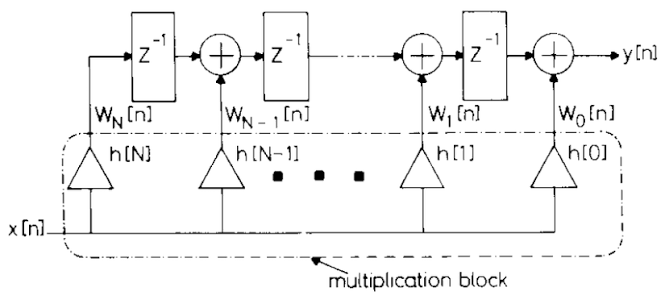

Tambien podrian plegarse los multiplicadores (de la misma forma que se realiza en el EJ4 de la GP2, para aprovechar la simetria de loa coeficientes, pero como no es el objetivo de la practica optimizar la implementacion, no es necesario)

## Cuantizacion del filtro

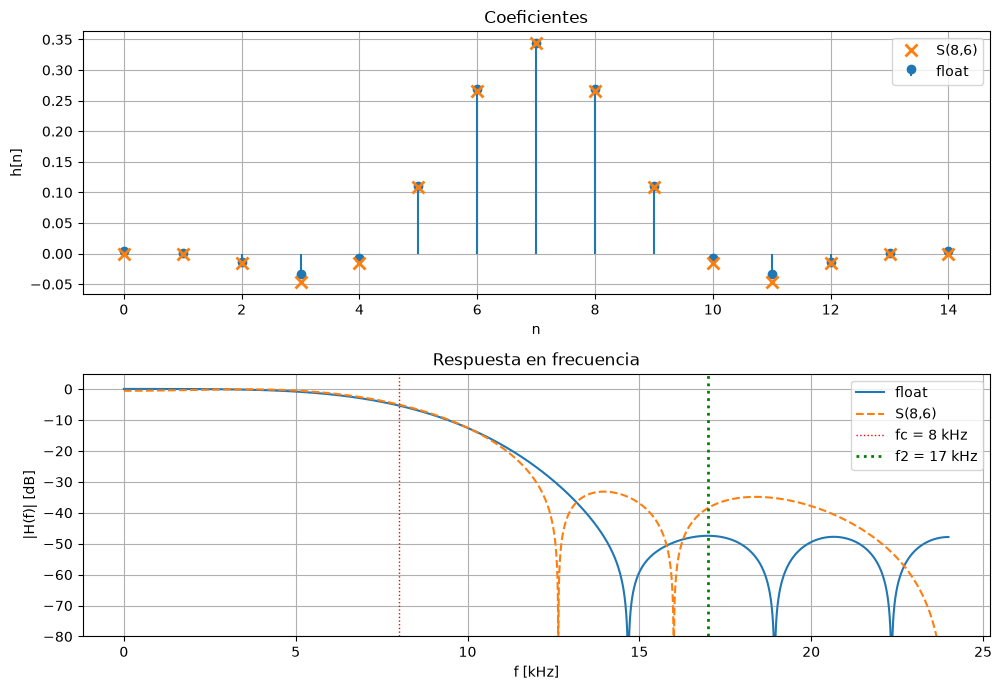

In [81]:
NB_LEN  = 8
NBF_LEN = 6
coeff = arrayFixedInt(NB_LEN, NBF_LEN, h)
h_q   = np.array([a.fValue for a in coeff])

w, H   = signal.freqz(h,   worN=N, fs=fs)
_, H_q = signal.freqz(h_q, worN=N, fs=fs)



# Plotteos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Coeficientes
n = np.arange(len(h))
ax1.stem(n, h,   linefmt='C0-', markerfmt='C0o', basefmt=' ', label='float')
ax1.plot(n, h_q, 'C1x', ms=8, mew=2, label='S(8,6)')
ax1.set_xlabel('n'); ax1.set_ylabel('h[n]')
ax1.set_title('Coeficientes')
ax1.grid(True); ax1.legend()

# Respuesta en frecuencia
ax2.plot(w/1e3, to_db(H),   label='float')
ax2.plot(w/1e3, to_db(H_q), '--', label='S(8,6)')
ax2.axvline(fc/1e3, color='r', ls=':', lw=1, label=f'fc = {fc/1e3:g} kHz')
ax2.axvline(17, color='g', ls=':', lw=2, label=f'f2 = {17:g} kHz')

ax2.set_xlabel('f [kHz]'); ax2.set_ylabel('|H(f)| [dB]')
ax2.set_title('Respuesta en frecuencia')
ax2.set_ylim(-80, 5)
ax2.grid(True); ax2.legend()

plt.tight_layout()
plt.show()

In [82]:

for i in range(len(h_q)):
    hq_int = int(h_q[i] * 2**NBF_LEN) # se desplazan 7 lugarees de la coma,
    hq_bin = hq_int & 0xFF
    print(f"h[{i:02}] = {h[i]:+.4f}  -->  h_q[{i:02}] = {h_q[i]:+.4f}  -->  hq_bin[{i:02}] = {hq_bin:02X}")

h[00] = +0.0038  -->  h_q[00] = +0.0000  -->  hq_bin[00] = 00
h[01] = +0.0014  -->  h_q[01] = +0.0000  -->  hq_bin[01] = 00
h[02] = -0.0130  -->  h_q[02] = -0.0156  -->  hq_bin[02] = FF
h[03] = -0.0330  -->  h_q[03] = -0.0469  -->  hq_bin[03] = FD
h[04] = -0.0068  -->  h_q[04] = -0.0156  -->  hq_bin[04] = FF
h[05] = +0.1101  -->  h_q[05] = +0.1094  -->  hq_bin[05] = 07
h[06] = +0.2684  -->  h_q[06] = +0.2656  -->  hq_bin[06] = 11
h[07] = +0.3438  -->  h_q[07] = +0.3438  -->  hq_bin[07] = 16
h[08] = +0.2684  -->  h_q[08] = +0.2656  -->  hq_bin[08] = 11
h[09] = +0.1101  -->  h_q[09] = +0.1094  -->  hq_bin[09] = 07
h[10] = -0.0068  -->  h_q[10] = -0.0156  -->  hq_bin[10] = FF
h[11] = -0.0330  -->  h_q[11] = -0.0469  -->  hq_bin[11] = FD
h[12] = -0.0130  -->  h_q[12] = -0.0156  -->  hq_bin[12] = FF
h[13] = +0.0014  -->  h_q[13] = +0.0000  -->  hq_bin[13] = 00
h[14] = +0.0038  -->  h_q[14] = +0.0000  -->  hq_bin[14] = 00


Se observa **claramente** como a la hora de cuantizar los coeficientes del filtro, se desplazan los zeros de transferencia, modificando asi el comportamiento del filtro en la banda de corte. Sin embargo, la banda de paso permanece (relativamente) inalterada. Como la banda de corte sigue estando a < -30db, sigue siendo aceptable.

Ademas, al analizar los efectos de cuantizacion sobre los coeficientes, se destaca que muchos recortan, o terminan valiendo cero. esto se da por que la representacion esta limitada (por el punto fijo). por lo cual la transaferencia se va a ver afectada.

In [83]:
for i in range(len(h_q)):
    hq_int = int(h_q[i] * 2**NBF_LEN) # se desplazan 6 lugarees de la coma,
    hq_bin = hq_int & 0xFF
    print(f"assign coef[{i}]  =  8'sh{hq_bin:02X};")
    

assign coef[0]  =  8'sh00;
assign coef[1]  =  8'sh00;
assign coef[2]  =  8'shFF;
assign coef[3]  =  8'shFD;
assign coef[4]  =  8'shFF;
assign coef[5]  =  8'sh07;
assign coef[6]  =  8'sh11;
assign coef[7]  =  8'sh16;
assign coef[8]  =  8'sh11;
assign coef[9]  =  8'sh07;
assign coef[10]  =  8'shFF;
assign coef[11]  =  8'shFD;
assign coef[12]  =  8'shFF;
assign coef[13]  =  8'sh00;
assign coef[14]  =  8'sh00;


## Generalizacion a cualquier FC

In [84]:
FS    = 48e3
TONOS = (1.5e3, 17e3)

def create_fir_PB(fc, taps, fs,  paso = None):
    if paso is None:
        paso = 1e3
    freq = [0, fc, fc + paso, fs/2]      
    gain = [1, 1, 0, 0]
    h = signal.firwin2(taps, freq, gain, fs=fs)
    return h 

def cuantizar_fir(h, NB_LEN = 8, NBF_LEN = 6):
    coeff = arrayFixedInt(NB_LEN, NBF_LEN, h)
    h_q   = np.array([a.fValue for a in coeff])
    return h_q

def respuesta_db(h, fs=FS, n_pts=4096):
    w, H = signal.freqz(h, worN=n_pts, fs=fs)
    return w, 20*np.log10(np.maximum(np.abs(H), 1e-6))   # evita log(0)

def ganancias_tonos(h, fs=FS):
    _, H = signal.freqz(h, worN=list(TONOS), fs=fs)
    return 20*np.log10(np.maximum(np.abs(H), 1e-6))

def plot_filter(h, h_q=None, fc=None, fs=FS, ax=None, NB_LEN=8, NBF_LEN=6):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    w, Hdb = respuesta_db(h, fs)
    ax.plot(w/1e3, Hdb, label='float')
    if h_q is not None:
        w, Hqdb = respuesta_db(h_q, fs)
        ax.plot(w/1e3, Hqdb, '--', label=f'S({NB_LEN},{NBF_LEN}) trunc')
    if fc is not None:
        ax.axvline(fc/1e3, color='k', ls=':', label=f'fc = {fc/1e3:g} kHz')
    for f in TONOS:
        ax.axvline(f/1e3, color='r', ls=':', alpha=0.5)
    ax.set_xlim(0, fs/2/1e3)
    ax.set_ylim(-80, 5)
    ax.set_xlabel('Frecuencia [kHz]')
    ax.set_ylabel('|H| [dB]')
    ax.set_title(f'Pasabajos fc = {fc/1e3:g} kHz' if fc else 'Respuesta en frecuencia')
    ax.grid(True)
    ax.legend(loc='lower left')
    return ax

def print_coefs(h_q, NBF_LEN = 6):
    for i in range(len(h_q)):
        hq_int = int(h_q[i] * 2**NBF_LEN) # se desplazan 6 lugarees de la coma,
        hq_bin = hq_int & 0xFF
        print(f"assign coef[{i}]  =  8'sh{hq_bin:02X};")

def create_pb_fir(fc, ax=None, taps=15, NB_LEN=8, NBF_LEN=6, fs=FS, paso=1e3):
    h   = create_fir_PB(fc, taps, fs, paso)
    h_q = cuantizar_fir(h, NB_LEN, NBF_LEN)
    plot_filter(h, h_q, fc=fc, fs=fs, ax=ax, NB_LEN=NB_LEN, NBF_LEN=NBF_LEN)

    g, gq = ganancias_tonos(h, fs), ganancias_tonos(h_q, fs)
    print(f"// ---------- fc = {fc/1e3:g} kHz ----------")
    print(f"// 1.5 kHz: {g[0]:+6.2f} dB float | {gq[0]:+6.2f} dB cuant.")
    print(f"// 17  kHz: {g[1]:+6.1f} dB float | {gq[1]:+6.1f} dB cuant.")
    print_coefs(h_q, NBF_LEN)
    print()
    return h, h_q

In [85]:
fcs = [0.5e3, 8e3, 18e3]
filtros = {}

// ---------- fc = 0.5 kHz ----------
// 1.5 kHz: -13.85 dB float | -18.65 dB cuant.
// 17  kHz:  -52.5 dB float |  -29.6 dB cuant.
assign coef[0]  =  8'sh00;
assign coef[1]  =  8'sh00;
assign coef[2]  =  8'sh00;
assign coef[3]  =  8'sh00;
assign coef[4]  =  8'sh01;
assign coef[5]  =  8'sh01;
assign coef[6]  =  8'sh01;
assign coef[7]  =  8'sh02;
assign coef[8]  =  8'sh01;
assign coef[9]  =  8'sh01;
assign coef[10]  =  8'sh01;
assign coef[11]  =  8'sh00;
assign coef[12]  =  8'sh00;
assign coef[13]  =  8'sh00;
assign coef[14]  =  8'sh00;



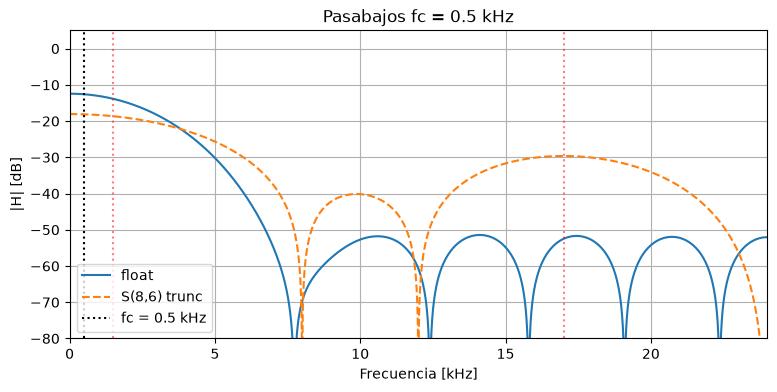

In [86]:
filtros[fcs[0]] = create_pb_fir(fcs[0])

// ---------- fc = 8 kHz ----------
// 1.5 kHz:  +0.03 dB float |  -0.38 dB cuant.
// 17  kHz:  -47.4 dB float |  -38.4 dB cuant.
assign coef[0]  =  8'sh00;
assign coef[1]  =  8'sh00;
assign coef[2]  =  8'shFF;
assign coef[3]  =  8'shFD;
assign coef[4]  =  8'shFF;
assign coef[5]  =  8'sh07;
assign coef[6]  =  8'sh11;
assign coef[7]  =  8'sh16;
assign coef[8]  =  8'sh11;
assign coef[9]  =  8'sh07;
assign coef[10]  =  8'shFF;
assign coef[11]  =  8'shFD;
assign coef[12]  =  8'shFF;
assign coef[13]  =  8'sh00;
assign coef[14]  =  8'sh00;



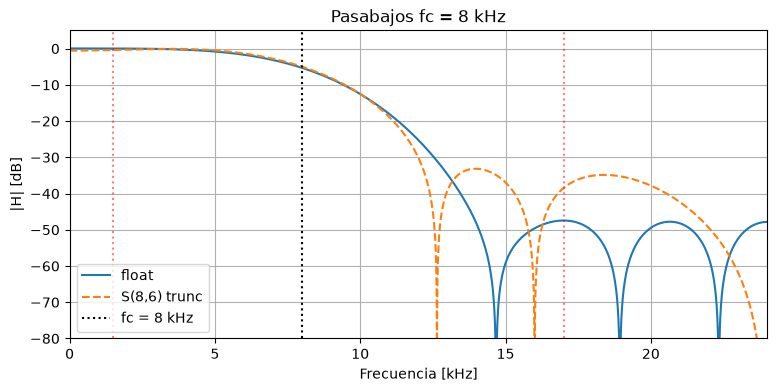

In [87]:
filtros[fcs[1]] = create_pb_fir(fcs[1])

// ---------- fc = 18 kHz ----------
// 1.5 kHz:  -0.00 dB float |  -0.71 dB cuant.
// 17  kHz:   -2.3 dB float |   -2.3 dB cuant.
assign coef[0]  =  8'shFF;
assign coef[1]  =  8'sh00;
assign coef[2]  =  8'shFF;
assign coef[3]  =  8'shFF;
assign coef[4]  =  8'sh03;
assign coef[5]  =  8'shF7;
assign coef[6]  =  8'sh0C;
assign coef[7]  =  8'sh32;
assign coef[8]  =  8'sh0C;
assign coef[9]  =  8'shF7;
assign coef[10]  =  8'sh03;
assign coef[11]  =  8'shFF;
assign coef[12]  =  8'shFF;
assign coef[13]  =  8'sh00;
assign coef[14]  =  8'shFF;



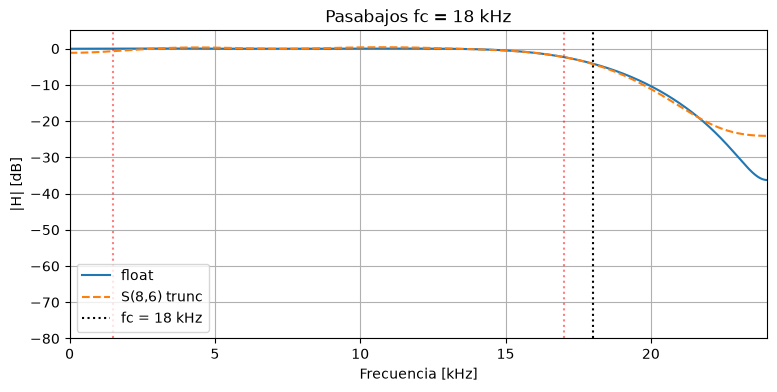

In [88]:
filtros[fcs[2]] = create_pb_fir(fcs[2])